# 01d – Monthly Performance

Análisis de variaciones estadísticas de cada equipo NBA a lo largo de los meses de la temporada regular. El objetivo es
detectar cambios en métricas clave mes a mes y comparar la evolución de anotación, eficiencia y margen de puntos.

Columnas clave utilizadas en este cuaderno:

- `SEASON_MONTH_NAME`: etiqueta del mes de temporada.
- `TEAM_NAME`: franquicia NBA.
- Métricas de rendimiento: `W`, `L`, `W_PCT`, `PTS`, `REB`, `AST`, `TOV`, `FG_PCT`, `FG3_PCT`, `FT_PCT`, `PLUS_MINUS`, `MIN`.


## Configuración

Definimos rutas del proyecto, cargamos las dependencias principales y aseguramos que existan las carpetas de salida para
tablas y figuras específicas del análisis mensual.


In [10]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (12, 6)

NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parents[3]
DATA_DIR = PROJECT_ROOT / "00_data"
FIGURES_DIR = PROJECT_ROOT / "02a_reports" / "figures" / "monthly"
TABLES_DIR = PROJECT_ROOT / "02a_reports" / "tables" / "monthly"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

INTERMEDIATE_PATH = Path("/Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00b_intermediate/team_dashboard/general_splits/2024-25/Regular Season/team_dashboard__general_splits.parquet")
DATASET_REFERENCE_ID = 3
SEASON_TARGET = "2024-25"

print(f"Proyecto: {PROJECT_ROOT}")
print(f"Parquet intermedio: {INTERMEDIATE_PATH}")
print(f"Dataset mensual (ID): {DATASET_REFERENCE_ID}")
print(f"Temporada objetivo: {SEASON_TARGET}")


Proyecto: /Users/pablo/Documents/BigData/BasketballAnalysis
Parquet intermedio: /Users/pablo/Documents/BigData/BasketballAnalysis/00_data/00b_intermediate/team_dashboard/general_splits/2024-25/Regular Season/team_dashboard__general_splits.parquet
Dataset mensual (ID): 3
Temporada objetivo: 2024-25


## Carga y filtrado de datos

Leemos el parquet consolidado, identificamos columnas relevantes (dataset, temporada y etiquetas de mes) y filtramos el
subset mensual (`dataset == 3`). Se imprime un resumen con la forma resultante, los equipos disponibles y los meses
presentes en el dataset.


In [11]:
MONTH_ORDER = ['October', 'November', 'December', 'January', 'February', 'March', 'April', 'May', 'June', 'July']

general_df = pd.read_parquet(INTERMEDIATE_PATH)
colmap = {c.lower(): c for c in general_df.columns}
df_month = general_df.copy()

season_col = colmap.get("season")
if season_col:
    df_month = df_month[df_month[season_col].astype(str) == SEASON_TARGET].copy()
    print(f"Filtro de temporada == {SEASON_TARGET} → filas: {len(df_month)}")
else:
    print("⚠️ No se encontró columna 'season'.")

dataset_col = colmap.get("dataset")
if dataset_col:
    dataset_numeric = pd.to_numeric(df_month[dataset_col], errors="coerce")
    mask = dataset_numeric == DATASET_REFERENCE_ID
    if mask.sum() == 0:
        dataset_str = df_month[dataset_col].astype(str).str.lower()
        target_tokens = {str(DATASET_REFERENCE_ID), f"dataset_{DATASET_REFERENCE_ID}"}
        mask = dataset_str.isin(target_tokens)
    df_month = df_month[mask].copy()
    print(f"Filtro dataset == {DATASET_REFERENCE_ID} → filas: {len(df_month)}")
else:
    print("⚠️ No se encontró columna 'dataset'.")

df_month_std = df_month.rename(columns={col: col.upper() for col in df_month.columns})
COLUMN_LOOKUP = {col: col for col in df_month_std.columns}

def require_columns(labels):
    missing = [label for label in labels if label not in COLUMN_LOOKUP]
    if missing:
        raise KeyError(f"Columnas faltantes en el parquet filtrado: {missing}")
    return [COLUMN_LOOKUP[label] for label in labels]

TEAM_COL = require_columns(["TEAM_NAME"])[0]
MONTH_COL = require_columns(["SEASON_MONTH_NAME"])[0]

print("---- RESULTADOS ----")
print("general_df shape:", general_df.shape)
print("df_month shape:", df_month.shape)
print("Columnas disponibles (estandarizadas):", sorted(df_month_std.columns))
print("Equipos únicos:", sorted(df_month_std[TEAM_COL].dropna().unique()))
month_unique = sorted(df_month_std[MONTH_COL].dropna().unique(), key=lambda m: MONTH_ORDER.index(m) if m in MONTH_ORDER else len(MONTH_ORDER))
print("Meses disponibles:", month_unique)

required_metrics = [
    "W", "L", "W_PCT", "PTS", "REB", "AST", "TOV", "FG_PCT", "FG3_PCT", "FT_PCT", "PLUS_MINUS", "MIN",
]
missing_metrics = [metric for metric in required_metrics if metric not in df_month_std.columns]
if missing_metrics:
    print(f"⚠️ Métricas faltantes: {missing_metrics}")
else:
    print("Todas las métricas solicitadas están disponibles.")

display(df_month_std.head())


Filtro de temporada == 2024-25 → filas: 672
Filtro dataset == 3 → filas: 240
---- RESULTADOS ----
general_df shape: (672, 69)
df_month shape: (240, 69)
Columnas disponibles (estandarizadas): ['AST', 'AST_RANK', 'BLK', 'BLKA', 'BLKA_RANK', 'BLK_RANK', 'DATASET', 'DREB', 'DREB_RANK', 'ENDPOINT', 'FG3A', 'FG3A_RANK', 'FG3M', 'FG3M_RANK', 'FG3_PCT', 'FG3_PCT_RANK', 'FGA', 'FGA_RANK', 'FGM', 'FGM_RANK', 'FG_PCT', 'FG_PCT_RANK', 'FTA', 'FTA_RANK', 'FTM', 'FTM_RANK', 'FT_PCT', 'FT_PCT_RANK', 'GAME_RESULT', 'GP', 'GP_RANK', 'GROUP_SET', 'GROUP_VALUE', 'L', 'L_RANK', 'MIN', 'MIN_RANK', 'OREB', 'OREB_RANK', 'PF', 'PFD', 'PFD_RANK', 'PF_RANK', 'PLUS_MINUS', 'PLUS_MINUS_RANK', 'PTS', 'PTS_RANK', 'REB', 'REB_RANK', 'SEASON', 'SEASON_MONTH_NAME', 'SEASON_SEGMENT', 'SEASON_TYPE', 'SEASON_YEAR', 'SOURCE_DATASET', 'SPLIT_TYPE', 'SPLIT_VALUE', 'STL', 'STL_RANK', 'TEAM_DAYS_REST_RANGE', 'TEAM_GAME_LOCATION', 'TEAM_ID', 'TEAM_NAME', 'TOV', 'TOV_RANK', 'W', 'W_PCT', 'W_PCT_RANK', 'W_RANK']
Equipos únicos: 

,GROUP_SET,GROUP_VALUE,SEASON_YEAR,GP,W,L,W_PCT,MIN,FGM,FGA,...,DATASET,TEAM_NAME,SOURCE_DATASET,SPLIT_TYPE,SPLIT_VALUE,TEAM_GAME_LOCATION,GAME_RESULT,SEASON_MONTH_NAME,SEASON_SEGMENT,TEAM_DAYS_REST_RANGE
188,Month,October,None,5,2,3,0.400,240.0,198,428,...,dataset_3,Atlanta Hawks,3,season_month_name,October,None,None,October,None,None
189,Month,November,None,16,8,8,0.500,768.0,692,1493,...,dataset_3,Atlanta Hawks,3,season_month_name,November,None,None,November,None,None
190,Month,December,None,12,8,4,0.667,586.0,523,1105,...,dataset_3,Atlanta Hawks,3,season_month_name,December,None,None,December,None,None
191,Month,January,None,15,4,11,0.267,725.0,606,1387,...,dataset_3,Atlanta Hawks,3,season_month_name,January,None,None,January,None,None
192,Month,February,None,12,5,7,0.417,581.0,531,1091,...,dataset_3,Atlanta Hawks,3,season_month_name,February,None,None,February,None,None


## Resumen general mensual

Calculamos las medias mensuales de las métricas principales. Se permite fijar un equipo específico con `TEAM_FILTER` para
concentrar el análisis en una franquicia concreta; por defecto se utilizan todos los registros disponibles.


In [12]:
TEAM_FILTER = None  # Ejemplo: 'Boston Celtics'

if TEAM_FILTER:
    df_focus = df_month_std[df_month_std[TEAM_COL] == TEAM_FILTER].copy()
    print(f"Filtrado por equipo: {TEAM_FILTER} → filas: {len(df_focus)}")
else:
    df_focus = df_month_std.copy()

metrics = ["W_PCT", "PTS", "REB", "AST", "TOV", "FG_PCT", "FG3_PCT", "FT_PCT", "PLUS_MINUS", "MIN"]
metric_cols = require_columns(metrics)

monthly_summary = (
    df_focus
    .groupby(MONTH_COL)[metric_cols]
    .mean(numeric_only=True)
    .round(3)
)

monthly_summary = (
    monthly_summary
    .reset_index()
    .assign(_ORDER=lambda df: pd.Categorical(df[MONTH_COL], categories=MONTH_ORDER, ordered=True))
    .sort_values('_ORDER')
    .drop(columns='_ORDER')
    .set_index(MONTH_COL)
)

display(monthly_summary)

monthly_summary_path = TABLES_DIR / 'monthly_summary.csv'
monthly_summary.to_csv(monthly_summary_path)
print('Resumen mensual exportado a', monthly_summary_path)

monthly_summary_reset = monthly_summary.reset_index()


,W_PCT,PTS,REB,AST,TOV,FG_PCT,FG3_PCT,FT_PCT,PLUS_MINUS,MIN
SEASON_MONTH_NAME,,,,,,,,,,
October,0.502,536.267,211.133,120.500,71.433,0.456,0.352,0.773,0.000,228.867
November,0.501,1669.333,646.667,387.700,217.067,0.466,0.360,0.780,0.000,714.733
December,0.496,1439.267,564.767,337.433,191.400,0.464,0.358,0.782,0.000,613.200
January,0.505,1715.300,666.267,402.000,212.833,0.469,0.361,0.778,0.000,729.733
February,0.502,1349.133,524.767,317.033,164.533,0.465,0.354,0.789,0.000,567.200
March,0.506,1823.200,692.467,426.533,217.300,0.473,0.367,0.783,0.000,764.600
April,0.495,801.167,311.133,185.867,97.900,0.472,0.361,0.766,0.000,339.000
July,0.478,535.867,229.467,115.767,94.933,0.427,0.320,0.746,1.133,239.503


Resumen mensual exportado a /Users/pablo/Documents/BigData/BasketballAnalysis/02a_reports/tables/monthly/monthly_summary.csv


### Visualizaciones mensuales

Se grafican tendencias de anotación (`PTS`) y porcentaje de victorias (`W_PCT`), así como las eficiencias de tiro y la
relación entre anotación y margen (`PLUS_MINUS`).


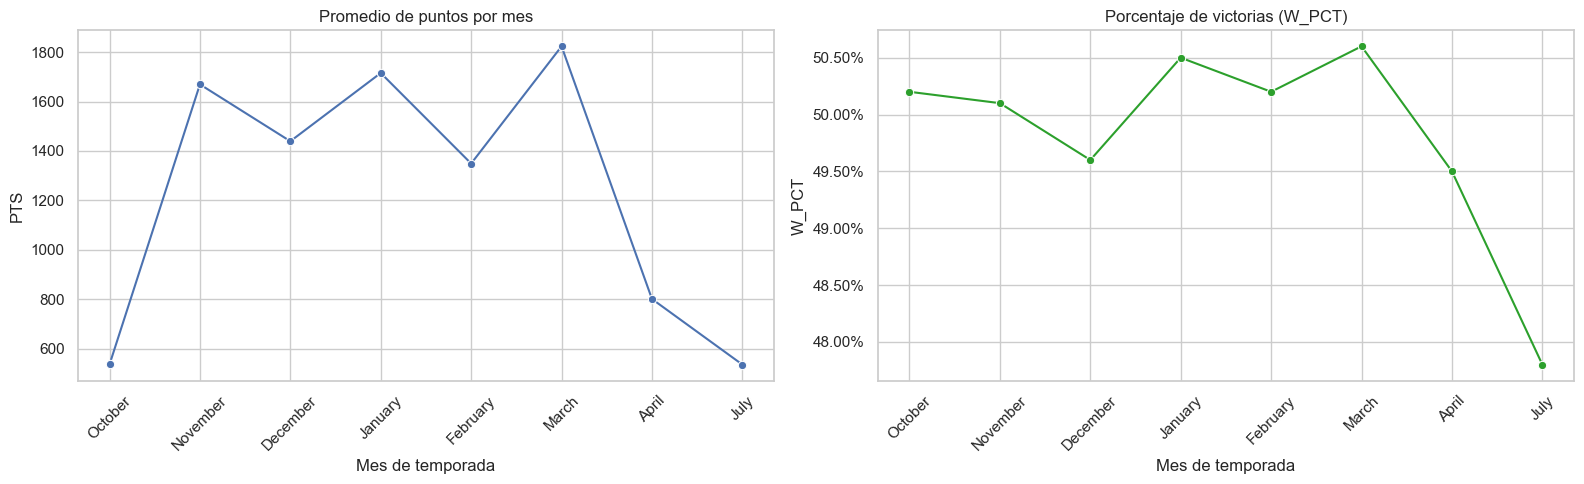

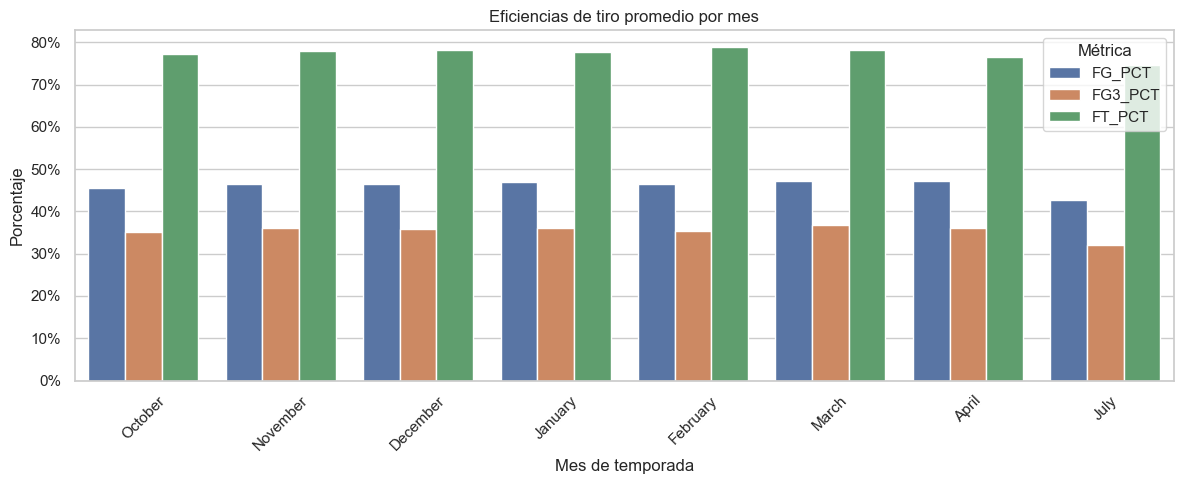

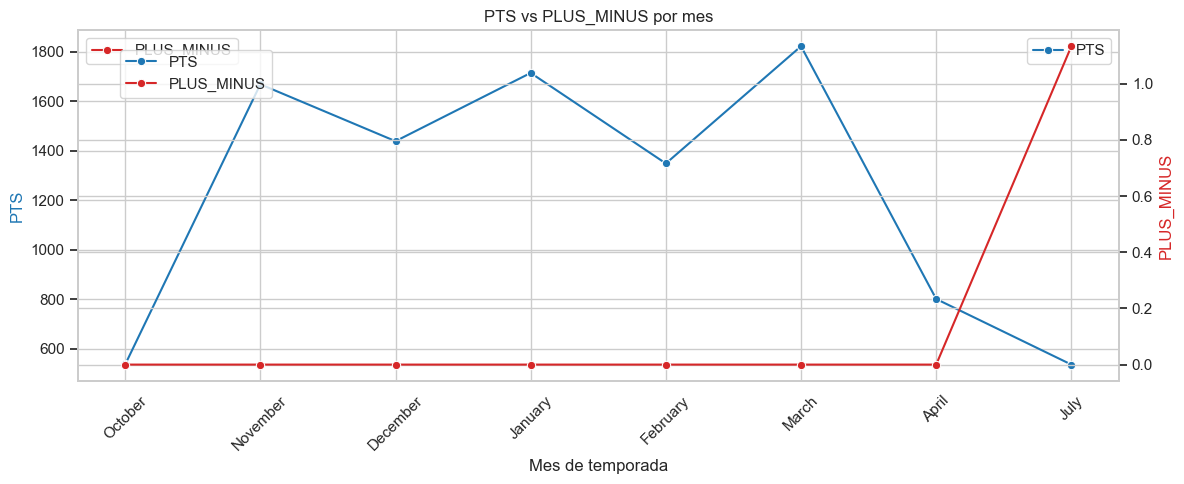

In [13]:
if monthly_summary_reset.empty:
    print('⚠️ No hay datos suficientes para generar visualizaciones.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
    sns.lineplot(data=monthly_summary_reset, x=MONTH_COL, y=require_columns(['PTS'])[0], marker='o', ax=axes[0])
    axes[0].set_title('Promedio de puntos por mes')
    axes[0].set_xlabel('Mes de temporada')
    axes[0].set_ylabel('PTS')
    axes[0].tick_params(axis='x', rotation=45)

    sns.lineplot(data=monthly_summary_reset, x=MONTH_COL, y=require_columns(['W_PCT'])[0], marker='o', ax=axes[1], color='tab:green')
    axes[1].set_title('Porcentaje de victorias (W_PCT)')
    axes[1].set_xlabel('Mes de temporada')
    axes[1].set_ylabel('W_PCT')
    axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    pct_cols = require_columns(['FG_PCT', 'FG3_PCT', 'FT_PCT'])
    pct_long = (
        monthly_summary_reset[[MONTH_COL] + pct_cols]
        .melt(id_vars=MONTH_COL, var_name='Metric', value_name='Value')
    )
    plt.figure(figsize=(12, 5))
    sns.barplot(data=pct_long, x=MONTH_COL, y='Value', hue='Metric')
    plt.title('Eficiencias de tiro promedio por mes')
    plt.xlabel('Mes de temporada')
    plt.ylabel('Porcentaje')
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.xticks(rotation=45)
    plt.legend(title='Métrica')
    plt.tight_layout()
    plt.show()

    pts_col = require_columns(['PTS'])[0]
    plus_col = require_columns(['PLUS_MINUS'])[0]
    fig, ax1 = plt.subplots(figsize=(12, 5))
    sns.lineplot(data=monthly_summary_reset, x=MONTH_COL, y=pts_col, marker='o', ax=ax1, color='tab:blue', label='PTS')
    ax1.set_xlabel('Mes de temporada')
    ax1.set_ylabel('PTS', color='tab:blue')
    ax1.tick_params(axis='x', rotation=45)

    ax2 = ax1.twinx()
    sns.lineplot(data=monthly_summary_reset, x=MONTH_COL, y=plus_col, marker='o', ax=ax2, color='tab:red', label='PLUS_MINUS')
    ax2.set_ylabel('PLUS_MINUS', color='tab:red')

    ax1.set_title('PTS vs PLUS_MINUS por mes')
    fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
    fig.tight_layout()
    plt.show()


## Tendencias y variaciones

Se calculan las variaciones mes a mes para métricas seleccionadas y se identifican los extremos de porcentaje de victorias
y margen de puntos.


In [14]:
if monthly_summary.empty:
    print('⚠️ El resumen mensual está vacío; no se pueden calcular diferencias.')
else:
    focus_metrics = require_columns(['W_PCT', 'PTS', 'REB', 'AST', 'TOV', 'FG_PCT'])
    monthly_diff = monthly_summary[focus_metrics].diff().round(3)
    display(monthly_diff)

    w_pct_col = require_columns(['W_PCT'])[0]
    plus_col = require_columns(['PLUS_MINUS'])[0]

    best_month = monthly_summary[w_pct_col].idxmax() if not monthly_summary.empty else None
    worst_month = monthly_summary[plus_col].idxmin() if not monthly_summary.empty else None

    extremes = []
    if best_month is not None:
        extremes.append({
            'Indicador': 'Mayor W_PCT',
            'Mes': best_month,
            'Valor': monthly_summary.loc[best_month, w_pct_col]
        })
    if worst_month is not None:
        extremes.append({
            'Indicador': 'Menor PLUS_MINUS',
            'Mes': worst_month,
            'Valor': monthly_summary.loc[worst_month, plus_col]
        })

    extremes_df = pd.DataFrame(extremes)
    display(extremes_df)


,W_PCT,PTS,REB,AST,TOV,FG_PCT
SEASON_MONTH_NAME,,,,,,
October,NaN,NaN,NaN,NaN,NaN,NaN
November,-0.001,1133.066,435.534,267.200,145.634,0.010
December,-0.005,-230.066,-81.900,-50.267,-25.667,-0.002
January,0.009,276.033,101.500,64.567,21.433,0.005
February,-0.003,-366.167,-141.500,-84.967,-48.300,-0.004
March,0.004,474.067,167.700,109.500,52.767,0.008
April,-0.011,-1022.033,-381.334,-240.666,-119.400,-0.001
July,-0.017,-265.300,-81.666,-70.100,-2.967,-0.045


,Indicador,Mes,Valor
0,Mayor W_PCT,March,0.506
1,Menor PLUS_MINUS,October,0.000


### Ranking mensual (opcional)

Si el parquet contiene columnas de ranking (`*_RANK`), se calcula la evolución promedio mensual para observar cambios en la
posición relativa de los equipos.


In [15]:
rank_candidates = ['W_PCT_RANK', 'PTS_RANK', 'REB_RANK', 'AST_RANK']
available_ranks = [col for col in rank_candidates if col in df_focus.columns]

if not available_ranks:
    print('No hay columnas de ranking disponibles en el dataset filtrado.')
else:
    rank_cols = require_columns(available_ranks)
    rank_summary = (
        df_focus.groupby(MONTH_COL)[rank_cols]
        .mean(numeric_only=True)
        .round(2)
    )
    rank_summary = (
        rank_summary.reset_index()
        .assign(_ORDER=lambda df: pd.Categorical(df[MONTH_COL], categories=MONTH_ORDER, ordered=True))
        .sort_values('_ORDER')
        .drop(columns='_ORDER')
        .set_index(MONTH_COL)
    )
    display(rank_summary)
    rank_summary_path = TABLES_DIR / 'monthly_rank_summary.csv'
    rank_summary.to_csv(rank_summary_path)
    print('Ranking promedio mensual exportado a', rank_summary_path)


,W_PCT_RANK,PTS_RANK,REB_RANK,AST_RANK
SEASON_MONTH_NAME,,,,
October,4.33,7.37,7.43,7.33
November,3.93,2.47,2.67,2.53
December,4.50,4.10,4.00,4.03
January,4.20,2.30,2.10,2.20
February,4.53,4.70,4.57,4.53
March,4.53,1.43,1.67,1.70
April,4.80,6.10,6.20,6.17
July,4.67,7.50,7.37,7.50


Ranking promedio mensual exportado a /Users/pablo/Documents/BigData/BasketballAnalysis/02a_reports/tables/monthly/monthly_rank_summary.csv


## Conclusiones

- Identificar qué meses muestran mayor porcentaje de victorias y margen positivo permite priorizar periodos de referencia
  para analizar estrategias y rotaciones exitosas.
- La comparación entre `FG_PCT`, `FG3_PCT` y `FT_PCT` facilita evaluar la relación entre eficiencia de tiro y resultados en
  el marcador (`W_PCT` y `PLUS_MINUS`).
- Revisar las variaciones mensuales de rebotes (`REB`) y pérdidas (`TOV`) ayuda a explicar rachas ofensivas o caídas en el
  ritmo de juego.
- El seguimiento opcional de rankings complementa la perspectiva cuantitativa al mostrar cambios en la posición relativa de
  los equipos durante la temporada.
